In [1]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
import keras.backend as K
from keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.layers import Dropout
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters
#sns.set(font_scale=1.5, style="whitegrid")
plt.style.use('seaborn')

2025-03-15 15:30:05.690333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-15 15:30:06.949434: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-15 15:30:07.426438: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-15 15:30:09.217480: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-15 15:30:21.527773: W tensorflow/compiler/tf2

In [2]:
# Set random seed for reproducibility
np.random.seed(1705)
tf.random.set_seed(1705)

In [3]:
# Read and explore data 
## chargement de la data initiale
dataset = pd.read_csv("/home/oem/Documents/these/code/Test_timeGAN/data/Dataset.csv", index_col="time", parse_dates=["time"])
print(dataset.shape)

(26040168, 10)


In [19]:
real_data= pd.read_csv('/home/oem/Documents/these/code/test_timGAN3/sample_test.csv', 
                  index_col='time',  parse_dates=['time']).sort_index()
real_data

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 00:00:00,-5.0,11.0,300.748985,64.278769,0.000176,570.753921,71.667998,0.006402,-2.444859,2.707218
2020-06-01 01:00:00,-5.0,11.0,300.576970,64.278731,0.000171,570.753921,72.434342,0.006416,-2.405108,2.770341
2020-06-01 02:00:00,-5.0,11.0,300.087648,64.278695,0.000170,570.753921,72.858137,0.006421,-2.348732,2.848998
2020-06-01 03:00:00,-5.0,11.0,299.807729,64.278660,0.000169,570.753921,73.270509,0.006430,-2.345248,2.930285
2020-06-01 04:00:00,-5.0,11.0,299.688487,64.278627,0.000163,570.753921,73.563993,0.006441,-2.401686,2.968036
...,...,...,...,...,...,...,...,...,...,...
2020-11-30 19:00:00,-5.0,11.0,302.156775,64.422136,0.000019,570.753921,71.966963,0.006253,3.102420,2.905387
2020-11-30 20:00:00,-5.0,11.0,300.229955,64.422067,0.000018,570.753921,72.046320,0.006256,2.785321,2.794370
2020-11-30 21:00:00,-5.0,11.0,299.623578,64.422007,0.000016,570.753921,71.997318,0.006253,2.509777,2.740080


In [4]:
dataset= dataset.fillna(0)
dataset.head()

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 00:00:00,-20.0,17.0,294.49365,296.0564,0.0,100,51.933450,0.000003,13.262855,12.979732
2020-06-01 01:00:00,-20.0,17.0,294.36896,296.0564,0.0,100,42.405025,0.000003,12.233408,11.928889
2020-06-01 02:00:00,-20.0,17.0,294.28415,296.0564,0.0,100,35.180350,0.000003,10.663969,12.199736
2020-06-01 03:00:00,-20.0,17.0,294.18920,296.0564,0.0,100,30.434422,0.000002,9.833769,13.402798
2020-06-01 04:00:00,-20.0,17.0,294.11337,296.0564,0.0,100,28.128063,0.000002,9.469925,14.455740


# Echantillonnage aléatoire de la base de données initiales

Vue la puissance de calcul trés faible à ma disposition, car mon laptop ne posséde pas de GPU, j'ai fait un random 

sampling de 1% de la base de données initiale.


In [5]:
# shuffle the DataFrame rows
data = dataset.sample(frac =0.01)
data.shape

(260402, 10)

In [8]:
# Ramener la variable time en colonne 
df=data.reset_index()
# Find the minimum and maximum dates

min_date = df['time'].min()
max_date = df['time'].max()

print('Minimum date:', min_date)
print('Maximum date:', max_date)

Minimum date: 2020-06-01 00:00:00
Maximum date: 2020-11-30 23:00:00


# Selectionner les mois de juin, juillet et Aout 

In [9]:
Data=dataset.loc['2020-06-01':'2020-08-31']
Data.shape

(13091232, 10)

In [11]:
Data.to_csv('Data.csv', header=True, index=True)

# Diviser l'ensemble de données en données de formation et de test

Dans ce projet, les premiers 60 % des données sont des données de formation, les 20 %  sont des données de test et 

les 20 % restants sont des données d'entrainement.

J'entraîne le modèle avec les données d'entraînement et je valide ses performances avec les données de test.

Dimension of train data:  (156240, 20)
Dimension of test data:  (52081, 20)
Dimension of validate data:  (52080, 20)


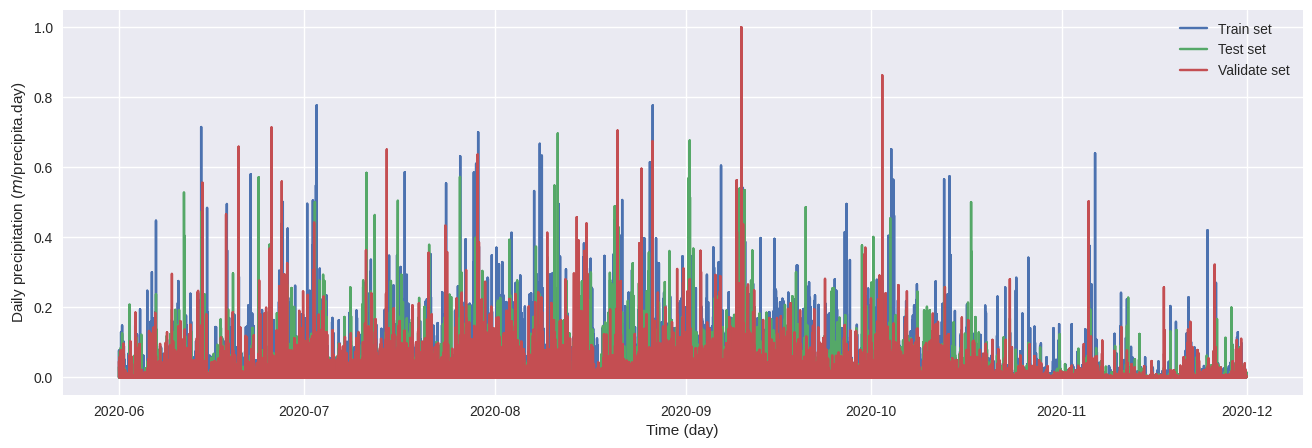

In [8]:
#train_size = int(len(data)*0.6)
#train_dataset, test_dataset = Data.iloc[:train_size], Data.iloc[train_size:]

# Plot train and test data
plt.figure(figsize = (16, 5))
plt.plot(train_data.Total_precip)
plt.plot(test_data.Total_precip)
plt.plot(validate_data.Total_precip)
plt.xlabel('Time (day)')
plt.ylabel('Daily precipitation ($m$/precipita.day)')
plt.legend(['Train set', 'Test set', 'Validate set'], loc='upper right')
#plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/2.jpg', format='jpg', dpi=1000)

print('Dimension of train data: ',train_data.shape)
print('Dimension of test data: ', test_data.shape)
print('Dimension of validate data: ',validate_data.shape)


#  Lagged Features in Time Series Forecasting

la modélisation prédictive des séries temporelles a souvent besoin d'aide pour prévoir avec précision les valeurs

futures, en particulier en présence de bruit et de modèles sous-jacents complexes.

L'utilisation des variables décalées (lagged features) améliore considérablement la prédiction des séries 

temporelles.

In [20]:
# Select the target variable and features
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m', 'SST','Total_precip','level', 
            'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']
# Normalize the data
scaler = MinMaxScaler()
scaler_target = MinMaxScaler()
scaler_data= np.concatenate([scaler.fit_transform(real_data[['longitude', 'latitude', 'Temp_2m', 'SST','level',
                                                        'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']]),
                                scaler_target.fit_transform(real_data[[target_variable]])], axis = 1)

real_data= pd.DataFrame(scaler_data, columns =['longitude', 'latitude', 'Temp_2m', 'SST','level', 'Rel_hum', 
                                          'Spec_hum', 'U_wind', 'V_wind','Total_precip'] ,index=real_data.index)

######################################## Create lag features
for feature in features:
    real_data[feature + '_lag1'] = real_data[feature].shift(1)
real_data.dropna(inplace=True)
# Update features list
lag_features = [f + '_lag1' for f in features]
all_features = features + lag_features

############################################### Another Split data into training and test sets
train_size = 0.8
validate_size = 0.2
train_data, test_data = np.split(real_data.sample(frac=1), [int(train_size * len(real_data))])

train_data= train_data.sort_index()
test_data= test_data.sort_index()
validate_data= validate_data.sort_index()
############################################
# Prepare data for LSTM
X_train = train_data[all_features].values
y_train = train_data[target_variable].values
X_test = test_data[all_features].values
y_test = test_data[target_variable].values
###########
date_train=train_data.index
date_test=test_data.index
# Reshape data for RNN input: Create a 3D Input Dataset:
## LSTM, GRU and BiLSTM take a 3D input (num_samples, num_timesteps, num_features)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

## Build the best modéle LSTM

In [21]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(hp.Int('input_unit',min_value=16,max_value=128,step=16),return_sequences=True, input_shape=(X_train.shape[1],X_train.shape[2])))
    for i in range(hp.Int('n_layers', 1, 10)):
        model.add(LSTM(hp.Int(f'lstm_{i}_units',min_value=16,max_value=128,step=16),return_sequences=True))
    model.add(LSTM(6))
    model.add(Dropout(hp.Float('Dropout_rate',min_value=0,max_value=0.5,step=0.1)))
    model.add(Dense(6))
    model.add(Dropout(hp.Float('Dropout_rate',min_value=0,max_value=0.5,step=0.1)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam',metrics = ['mse'])
    return model

In [22]:
tuner= kt.RandomSearch(
        build_model,
        objective='mse',
        max_trials=10,
        executions_per_trial=2,
        directory="/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive",
        project_name="tuning_best_lstm"
)


/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
tuner.search(
        x=X_train,
        y=y_train,
        epochs=20,
        batch_size=128,
        validation_data=(X_test,y_test),
)

Trial 10 Complete [00h 01m 08s]
mse: 0.00012514489571913145

Best mse So Far: 0.00012514489571913145
Total elapsed time: 00h 07m 24s


In [15]:
print(tuner.results_summary())

Results summary
Results in /home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/tuning_best_lstm
Showing 10 best trials
Objective(name="mse", direction="min")

Trial 05 summary
Hyperparameters:
input_unit: 112
n_layers: 4
lstm_0_units: 96
Dropout_rate: 0.0
lstm_1_units: 96
lstm_2_units: 128
lstm_3_units: 96
lstm_4_units: 96
lstm_5_units: 16
lstm_6_units: 32
lstm_7_units: 128
lstm_8_units: 32
Score: 8.110955036499945e-07

Trial 07 summary
Hyperparameters:
input_unit: 64
n_layers: 7
lstm_0_units: 32
Dropout_rate: 0.0
lstm_1_units: 96
lstm_2_units: 16
lstm_3_units: 128
lstm_4_units: 16
lstm_5_units: 48
lstm_6_units: 32
lstm_7_units: 112
lstm_8_units: 128
Score: 0.00046125998778734356

Trial 02 summary
Hyperparameters:
input_unit: 32
n_layers: 8
lstm_0_units: 32
Dropout_rate: 0.1
lstm_1_units: 96
lstm_2_units: 16
lstm_3_units: 64
lstm_4_units: 80
lstm_5_units: 80
lstm_6_units: 112
lstm_7_units: 48
lstm_8_units: 128
Score: 0.00046126045344863087

Trial 00 summary
Hype

In [24]:
# Get the top 2 models.
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 112)         │        59,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │       123,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 112)         │       107,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 80)          │        61,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 16)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 1, 48)          │        12,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 1, 96)          │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 128)         │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 1, 32)          │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 6)              │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 563,865 (2.15 MB)

 Trainable params: 563,865 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

## Plot train loss vs validation loss

In [15]:
plt.style.use('seaborn-whitegrid')
def plot_loss (history, model_name):
    plt.figure(figsize = (16, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/loss_'+model_name+'.jpg', format='jpg', dpi=1000)


plot_loss (history, 'LSTM')


/tmp/ipykernel_56045/1490102.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


NameError: name 'history' is not defined

# Make prediction using Best modele LSTM

In [25]:
import cmath
def prediction(model):
    prediction = model.predict(X_test)
    prediction = scaler_target.inverse_transform(prediction)
    return prediction

prediction_lstm = prediction(best_model)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step


In [26]:
y_test=y_test.reshape(-1,1)
y_train=y_train.reshape(-1,1)
Y_test = scaler_target.inverse_transform(y_test)
Y_train = scaler_target.inverse_transform(y_train)

# Plot true future (test) vs prediction

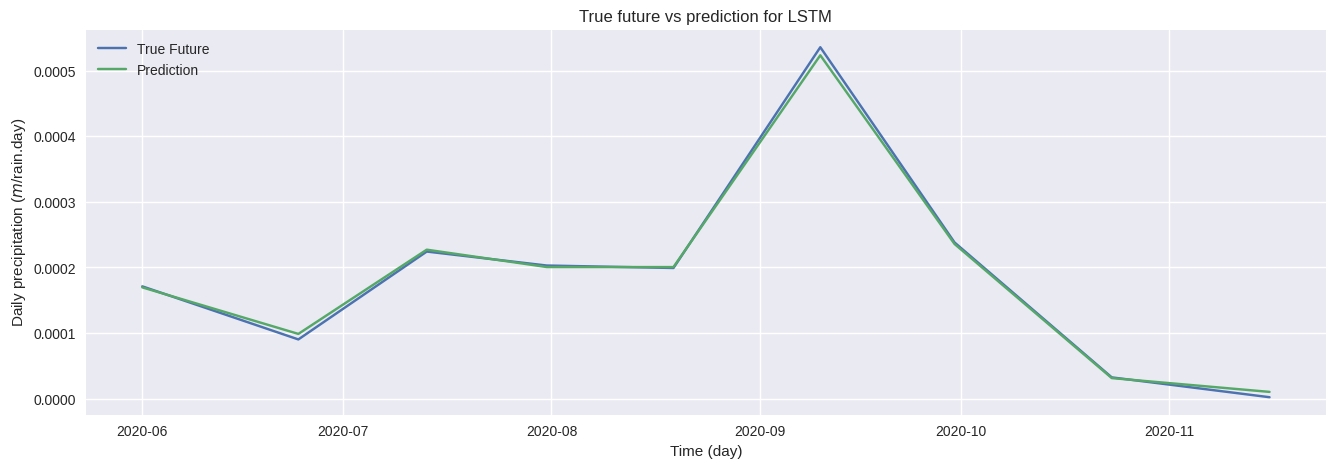

In [27]:
def plot_future(prediction, model_name, y_test):
    
    plt.figure(figsize=(16, 5))
    
    range_future =100

    plt.plot(date_test[::range_future], np.array(Y_test[::range_future]), label='True Future')
    plt.plot(date_test[::range_future], np.array(prediction[::range_future]),label='Prediction')

    plt.title('True future vs prediction for ' + model_name)
    plt.legend(loc='upper left')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/rain.day)')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/predic_'+model_name+'.jpg', format='jpg', dpi=1000)
    
    

plot_future(prediction_lstm, 'LSTM', Y_test)


# Calculate MSE , MAE and RMSE

In [28]:
# Define a function to calculate MAE and RMSE
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()

    print(model_name + ':')
    print('Mean Squared  Error: {:.15f}'.format(mse))
    print('Mean Absolute Error: {:.10f}'.format(mae))
    print('Root Mean Square Error: {:.10f}'.format(rmse))
    print('')



evaluate_prediction(prediction_lstm, Y_test, 'LSTM')



LSTM:
Mean Squared  Error: 0.000000000085254
Mean Absolute Error: 0.0000068032
Root Mean Square Error: 0.0000092333



In [30]:
from keras import models  
## Save the best modele
best_model=models.save('SolarLSTM.h5')
#save_model(best_model,'SolarLSTM.h5')

AttributeError: module 'keras.models' has no attribute 'save'

## Test de Validation

In [22]:
X_val = validate_data[all_features].values
y_val = validate_data[target_variable].values
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
def prediction(model):
    prediction = model.predict(X_val)
    prediction = scaler_target.inverse_transform(prediction)
    return prediction

Prediction = prediction(best_model)
y_val=y_val.reshape(-1,1)
Y_val = scaler_target.inverse_transform(y_val)

1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


/tmp/ipykernel_56045/1315784545.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


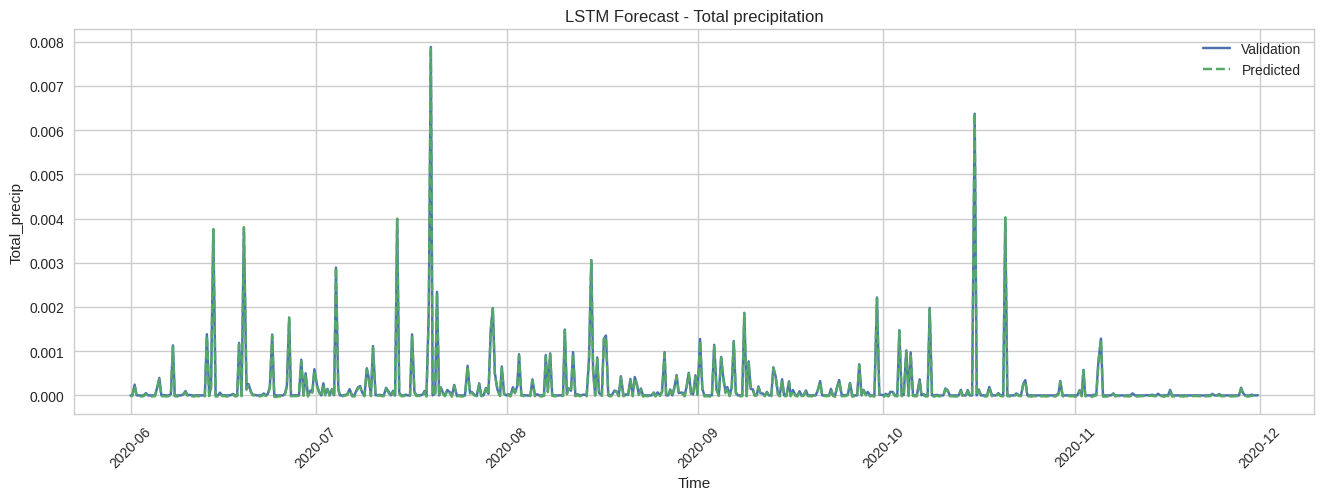

In [23]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
## Visualisation échantillon
range_validation = 100
plt.figure(figsize=(16, 5))
plt.plot(validate_data.index[::range_validation], Y_val[::range_validation], label='Validation')
plt.plot(validate_data.index[::range_validation], Prediction[::range_validation], label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation')
plt.legend()
plt.show()

# Benchmark  avec les données synthétique générées par TimeGAN

Nous allons faire le même travail de prédiction avec la meilleur architecture de LSTM avec une base de données 

générées par TimeGAM.

L'objectif est de tester si les données synthétiques aurons les meilleurs performances que les données réelles. 

In [3]:
## Chargement des données synthétique au format h5
df = pd.read_hdf('/home/oem/Documents/these/code/test_timGAN3/time_gan/TimeSeriesGAN.h5')
# Permet de ramener time au format datetime 
df['time'] = pd.to_datetime(df['time']).round('min')
df= df.set_index('time')
## Ordonner selon le time
df=df.sort_index()
print(df.shape)

(104448, 10)


In [4]:
df.head()

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 22:33:00,-4.999974,11.000027,303.804565,300.636078,0.000417,570.753906,61.981068,0.005905,-5.745670,1.317925
2020-06-01 22:47:00,-4.999958,11.000046,301.164307,300.639099,0.000073,570.753967,81.070961,0.006910,-4.633053,2.737418
2020-06-01 23:23:00,-4.999959,11.000043,301.648743,300.653473,0.000075,570.753967,80.488403,0.006888,-4.600108,2.603792
2020-06-01 23:28:00,-4.999969,11.000032,304.012970,300.643982,0.000451,570.753967,63.262444,0.005921,-5.391344,1.070914
2020-06-01 23:35:00,-4.999970,11.000027,301.455322,300.689240,0.000057,570.753967,76.728134,0.006809,-4.783827,1.775245


## Lagged Features in Time Series Forecasting

In [5]:
# Select the target variable and features
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m', 'SST','Total_precip','level', 
            'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']
# Normalize the data
scaler = MinMaxScaler()
scaler_target = MinMaxScaler()
scaler_synthetic= np.concatenate([scaler.fit_transform(df[['longitude', 'latitude', 'Temp_2m', 'SST','level',
                                                        'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']]),
                                scaler_target.fit_transform(df[[target_variable]])], axis = 1)

synthetic_data= pd.DataFrame(scaler_synthetic, columns =['longitude', 'latitude', 'Temp_2m', 'SST','level', 'Rel_hum', 
                                          'Spec_hum', 'U_wind', 'V_wind','Total_precip'] ,index=df.index)

######################################## Create lag features
for feature in features:
    synthetic_data[feature + '_lag1'] = synthetic_data[feature].shift(1)
synthetic_data.dropna(inplace=True)
# Update features list
lag_features = [f + '_lag1' for f in features]
all_features = features + lag_features

############################################### Another Split data into training and test sets
train_size = 0.6
validate_size = 0.2
train_synthetic, validate_synthetic, test_synthetic = np.split(synthetic_data.sample(frac=1), [int(train_size * len(synthetic_data)), 
                                                          int((validate_size + train_size) * len(synthetic_data))])

train_synthetic= train_synthetic.sort_index()
test_synthetic= test_synthetic.sort_index()
validate_synthetic= validate_synthetic.sort_index()
############################################
# Prepare data for LSTM
X_train = train_synthetic[all_features].values
y_train = train_synthetic[target_variable].values
X_test = test_synthetic[all_features].values
y_test = test_synthetic[target_variable].values
################## 
date_train=train_synthetic.index
date_test=test_synthetic.index
# Reshape data for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

## Build the best modéle LSTM

In [6]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(hp.Int('input_unit',min_value=16,max_value=128,step=16),return_sequences=True, input_shape=(X_train.shape[1],X_train.shape[2])))
    for i in range(hp.Int('n_layers', 1, 10)):
        model.add(LSTM(hp.Int(f'lstm_{i}_units',min_value=16,max_value=128,step=16),return_sequences=True))
    model.add(LSTM(6))
    model.add(Dropout(hp.Float('Dropout_rate',min_value=0,max_value=0.5,step=0.1)))
    model.add(Dense(6))
    model.add(Dropout(hp.Float('Dropout_rate',min_value=0,max_value=0.5,step=0.1)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam',metrics = ['mse'])
    return model

In [7]:
tuner= kt.RandomSearch(
        build_model,
        objective='mse',
        max_trials=10,
        executions_per_trial=2,
        directory="/home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive",
        project_name="tuning_best_lstm_synth"
)


/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
tuner.search(
        x=X_train,
        y=y_train,
        epochs=20,
        batch_size=128,
        validation_data=(X_test,y_test),
)

Trial 10 Complete [00h 06m 01s]
mse: 0.003572572022676468

Best mse So Far: 3.923988288079272e-06
Total elapsed time: 00h 55m 12s


In [9]:
print(tuner.results_summary())

Results summary
Results in /home/oem/Documents/these/code/LSTM_GRU_BiLSTM_in_TensorFlow_for_predictive/tuning_best_lstm_synth
Showing 10 best trials
Objective(name="mse", direction="min")

Trial 05 summary
Hyperparameters:
input_unit: 128
n_layers: 8
lstm_0_units: 112
Dropout_rate: 0.0
lstm_1_units: 128
lstm_2_units: 128
lstm_3_units: 112
lstm_4_units: 128
lstm_5_units: 16
lstm_6_units: 128
lstm_7_units: 32
Score: 3.923988288079272e-06

Trial 06 summary
Hyperparameters:
input_unit: 112
n_layers: 1
lstm_0_units: 96
Dropout_rate: 0.1
lstm_1_units: 96
lstm_2_units: 112
lstm_3_units: 112
lstm_4_units: 80
lstm_5_units: 32
lstm_6_units: 80
lstm_7_units: 64
Score: 0.001619521004613489

Trial 03 summary
Hyperparameters:
input_unit: 128
n_layers: 8
lstm_0_units: 96
Dropout_rate: 0.1
lstm_1_units: 96
lstm_2_units: 80
lstm_3_units: 16
lstm_4_units: 80
lstm_5_units: 80
lstm_6_units: 48
lstm_7_units: 16
Score: 0.00164389907149598

Trial 04 summary
Hyperparameters:
input_unit: 80
n_layers: 1
lstm_0_

In [10]:
# Get the top 2 models.
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 112)         │       107,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 128)         │       123,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 112)         │       107,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 1, 128)         │       123,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 1, 16)          │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 128)         │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 1, 32)          │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 6)              │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,705 (2.96 MB)

 Trainable params: 775,705 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

## Make prediction using Best modele LSTM

In [11]:
def prediction(model):
    prediction = model.predict(X_test)
    prediction = scaler_target.inverse_transform(prediction)
    return prediction

prediction_lstm = prediction(best_model)


653/653 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


In [12]:
y_test=y_test.reshape(-1,1)
y_train=y_train.reshape(-1,1)
Y_test = scaler_target.inverse_transform(y_test)
Y_train = scaler_target.inverse_transform(y_train)

## Plot true future (test) vs prediction

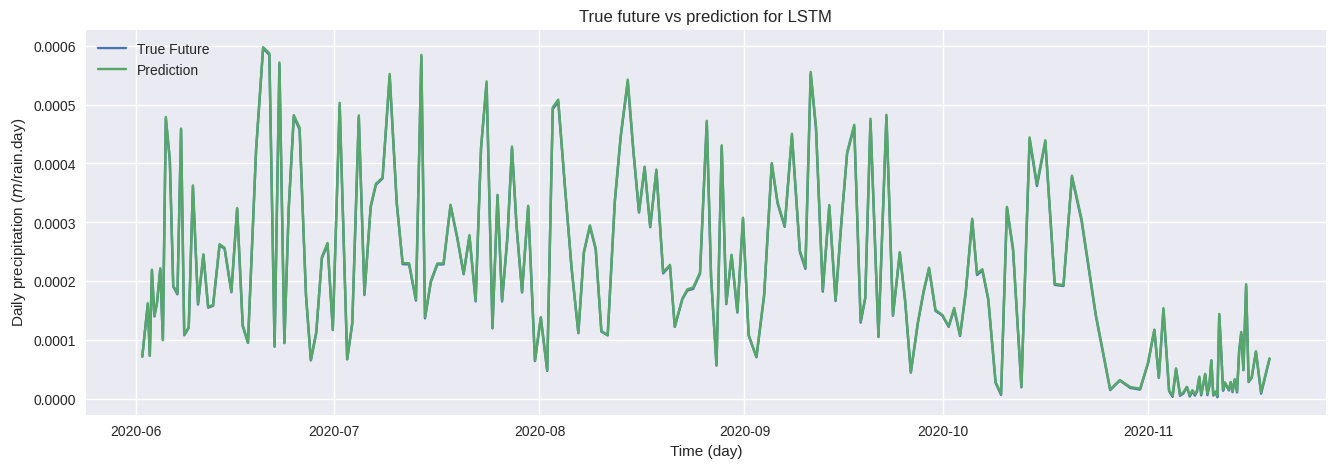

In [13]:
def plot_future(prediction, model_name, y_test):
    
    plt.figure(figsize=(16, 5))
    
    range_future =100

    plt.plot(date_test[::range_future], np.array(Y_test[::range_future]), label='True Future')
    plt.plot(date_test[::range_future], np.array(prediction[::range_future]),label='Prediction')

    plt.title('True future vs prediction for ' + model_name)
    plt.legend(loc='upper left')
    plt.xlabel('Time (day)')
    plt.ylabel('Daily precipitation ($m$/rain.day)')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/predic_'+model_name+'.jpg', format='jpg', dpi=1000)
    
    

plot_future(prediction_lstm, 'LSTM', Y_test)


## Calculate MSE , MAE and RMSE

In [14]:
# Define a function to calculate MAE and RMSE
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()

    print(model_name + ':')
    print('Mean Squared  Error: {:.15f}'.format(mse))
    print('Mean Absolute Error: {:.10f}'.format(mae))
    print('Root Mean Square Error: {:.10f}'.format(rmse))
    print('')



evaluate_prediction(prediction_lstm, Y_test, 'LSTM')



LSTM:
Mean Squared  Error: 0.000000000003627
Mean Absolute Error: 0.0000017227
Root Mean Square Error: 0.0000019046



## Test de Validation 

In [17]:
X_val = validate_synthetic[all_features].values
y_val = validate_synthetic[target_variable].values
X_val = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
def prediction(model):
    prediction = model.predict(X_val)
    prediction = scaler_target.inverse_transform(prediction)
    return prediction

Prediction = prediction(best_model)
y_val=y_val.reshape(-1,1)
Y_val = scaler_target.inverse_transform(y_val)

653/653 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


NotFittedError: This MinMaxScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
## Visualisation échantillon
range_validation = 100
plt.figure(figsize=(16, 5))
plt.plot(validate_data.index[::range_validation], Y_val[::range_validation], label='Validation')
plt.plot(validate_data.index[::range_validation], Prediction[::range_validation], label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation')
plt.legend()
plt.show()

In [19]:
### Différence en pourcentage %
D=0.000000000075515- 0.000000000003627
S=0.000000000075515+ 0.000000000003627
C=S/2
P=(D/C)*100
P

181.6683935205074